Vamos a construir el algoritmo para hacer la reconstrucción de la ec de estado de la energía oscura. Hay que tener en cuenta que esto se correrá en un algoritmo de MCMC. 

1. MCMC propone w_i a través de GP (según el kernel y media)
2. interpolar w(z)
3. integrar
4. Calcular H(z)
5. Calcular distancias de BAO (segunda integral)
6. evaluar likelihood

In [57]:
import matplotlib as mpl

In [58]:
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",        # 'cm', 'stix', 'stixsans', 'dejavusans'
    "font.serif": ["STIXGeneral", "Times New Roman"],
    "axes.unicode_minus": False,
    "figure.dpi": 120,
    "figure.figsize": (8,5)
})

In [59]:
#paleta de colores

colors = ['#C39BD3', '#F7DC6F', '#EF91CB', '#48C9B0', '#98FB98', '#FA8072', '#3498DB']

In [60]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import emcee
from scipy import integrate, interpolate
import camb

Primero vamos a escribir los datos que utilizaremos. Para este proyecto esto es BAO DESIDR2

In [61]:
data = {
    "Tracer": ["BGS", "LRG1", "LRG2", "LRG3+ELG1", "ELG2", "QSO", "Lya"],
    "z_eff": [0.295, 0.510, 0.706, 0.934, 1.321, 1.484, 2.330],
    "DV/rd": [7.942, 12.720, 16.050, 19.721, 24.252, 26.055, 31.267],
    "sigma_DV/rd": [0.075, 0.099, 0.110, 0.091, 0.174, 0.398, 0.256],
    "DM/DH": [None, 0.622, 0.892, 1.223, 1.948, 2.386, 4.518],
    "sigma_DM/DH": [None, 0.017, 0.021, 0.019, 0.045, 0.136, 0.097],
    "r_V,M/H": [None, 0.050, -0.018, 0.056, 0.202, 0.044, 0.574],
    "DM/rd": [None, 13.588, 17.351, 21.576, 27.601, 30.512, 38.988],
    "sigma_DM/rd": [None,0.167, 0.177, 0.152, 0.318, 0.760, 0.531],
    "DH/rd": [None, 21.863, 19.455, 17.641, 14.176, 12.817, 8.632],
    "sigma_DH/rd": [None,0.425, 0.330, 0.193, 0.221, 0.516, 0.101],
    "r_M,H": [None, -0.459, -0.404, -0.416, -0.434, -0.500, -0.431]
}

df = pd.DataFrame(data)
print(df)

      Tracer  z_eff   DV/rd  sigma_DV/rd  DM/DH  sigma_DM/DH  r_V,M/H   DM/rd  \
0        BGS  0.295   7.942        0.075    NaN          NaN      NaN     NaN   
1       LRG1  0.510  12.720        0.099  0.622        0.017    0.050  13.588   
2       LRG2  0.706  16.050        0.110  0.892        0.021   -0.018  17.351   
3  LRG3+ELG1  0.934  19.721        0.091  1.223        0.019    0.056  21.576   
4       ELG2  1.321  24.252        0.174  1.948        0.045    0.202  27.601   
5        QSO  1.484  26.055        0.398  2.386        0.136    0.044  30.512   
6        Lya  2.330  31.267        0.256  4.518        0.097    0.574  38.988   

   sigma_DM/rd   DH/rd  sigma_DH/rd  r_M,H  
0          NaN     NaN          NaN    NaN  
1        0.167  21.863        0.425 -0.459  
2        0.177  19.455        0.330 -0.404  
3        0.152  17.641        0.193 -0.416  
4        0.318  14.176        0.221 -0.434  
5        0.760  12.817        0.516 -0.500  
6        0.531   8.632        0.101 

In [62]:
#Graficamos
from astropy.cosmology import Planck18, FlatLambdaCDM
import astropy.units as u
import astropy.constants as const

# Puedes usar un modelo predefinido:
cosmo = Planck18   # parámetros cosmológicos del Planck 2018

# O definir el tuyo:
#cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

In [63]:
#definimos nuestro rango de redshift
z = np.linspace(0.1,2.5,10000)

#Distancias en distancias que mandeja DESI

# Distancia comóvil transversal D_M
D_M = lambda z:cosmo.comoving_transverse_distance(z)  # en Mpc

# Distancia de Hubble D_H = c / H(z)
D_H = lambda z:(const.c / cosmo.H(z)).to(u.Mpc)

# Distancia combinada (esférica) D_V = [ D_M^2 * cz/H(z) ]^(1/3)
D_V = lambda z: ((D_M(z)**2 * (const.c * z / cosmo.H(z)).to(u.Mpc)).value) ** (1/3) * u.Mpc

#definimos el horizonte de sonido
r_d = 147.09 * u.Mpc

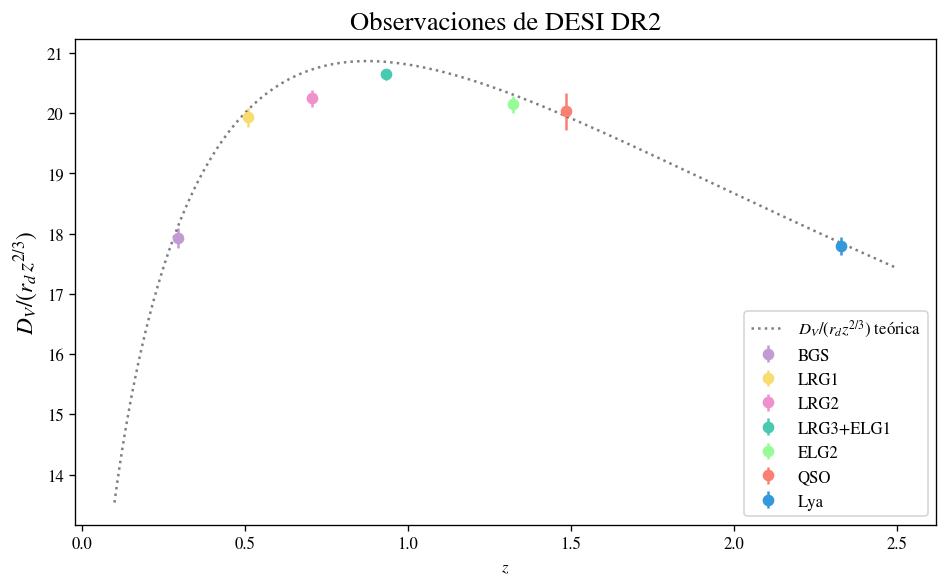

In [64]:
#ploteamos distancias para ver que todo está en orden
plt.figure(figsize=(8,5))
for i in range(len(df)):
    plt.errorbar(
        df['z_eff'][i],
        df['DV/rd'][i] * df['z_eff'][i]**(-2/3),
        df["z_eff"][i]**(-2/3) * df["sigma_DV/rd"][i],
        fmt='o',
        color=colors[i],
        label = df['Tracer'][i]
    )
plt.plot(z,D_V(z)/(r_d*(z**(2/3))),linestyle = 'dotted',color='black',alpha=0.5,label = '$D_V / (r_d z^{2/3})$ teórica')
plt.legend()
plt.xlabel("$z$")
plt.ylabel(r"$ D_V/(r_d\,z^{2/3})$", fontsize=14)
plt.title("Observaciones de DESI DR2",fontsize=16)
plt.tight_layout()
plt.show()

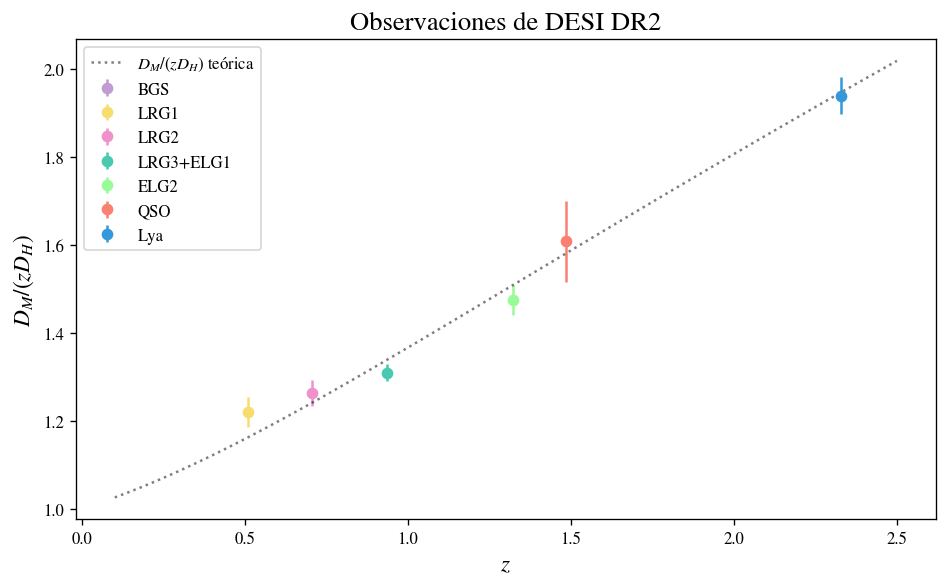

In [65]:
plt.figure(figsize=(8,5))
for i in range(len(df)):
    plt.errorbar(
        df['z_eff'][i],
        df['DM/DH'][i] / df['z_eff'][i],
        df['sigma_DM/DH'][i] / df['z_eff'][i],
        fmt='o',
        color=colors[i],
        label = df['Tracer'][i]
        )

plt.plot(z,D_M(z)/(z*D_H(z)),linestyle = 'dotted',color='black',alpha = 0.5, label = '$D_M / (z D_H )$ teórica')
plt.legend()
plt.xlabel("$z$",fontsize =14)
plt.ylabel(r"$D_M / (z D_H )$",fontsize = 14)
plt.title("Observaciones de DESI DR2",fontsize= 16)
plt.tight_layout()
plt.show()

Hasta acá solo hemos cargado los datos. Ahora vamos a contruir las funciones que necesitamos. Esto es:
1. El kernel que definirá el GP así como el GP de la integral ()
2. Las funciones de distancias con camb que utilizaremos para meter en la likelihood
3. Los priors de los parámetros que precisamente se definen a partir de la función kernel
4. La likelihood

In [66]:
from sklearn.gaussian_process import kernels
#from sklearn.gaussian_process import GaussianProcessRegressor por si acaso

In [106]:
m = 50
h = 3
z_nodes_part = np.linspace(0, 3, m)                    # 70 nodos GP
z_nodes_full = np.linspace(0, 3, (m - 1) * h + 1)  
print(np.size(z_nodes_part),np.size(z_nodes_full))

50 148


In [107]:
def distancias(z_nodes, y_nodes, z_obs, 
               H0=67.66, Om=0.30966, ODE=0.69034, rd=147.09):

    c_km_s = const.c.to(u.km / u.s).value

    # interpolamos y(z) dados los y_nodes dle GP
    # y_interp = interpolate.interp1d(z_nodes, y_nodes,
    #                     kind="cubic",
    #                     fill_value="extrapolate")

    # #grid para integrar (m*h puntos)
    # z_max = max(z_obs)
    # z_grid = np.linspace(0, z_max, m * h)

    # # evaluar y(z) (la función que obtuvimos por la interpolación en una rejilla para integrar después)
    # y_grid = y_interp(z_grid) #obtenemos m*h puntos 

    # evaluamos en f(z)
    f_grid = (1 + z_nodes)**3 * np.exp(3*y_nodes)

    # hubble
    Hz = H0 * np.sqrt(Om * (1 + z_nodes)**3 + ODE * f_grid)

    # distancia comóvil (integral c trapezoide)
    invH = 1.0 / Hz
    chi_grid = c_km_s * integrate.cumulative_trapezoid(invH, z_nodes, initial=0.0)

    # interpolar a z_obs
    chi_interp = interpolate.interp1d(z_nodes, chi_grid, kind="cubic")
    H_interp   = interpolate.interp1d(z_nodes, Hz, kind="cubic")

    chi = chi_interp(z_obs)
    Hz_obs = H_interp(z_obs)

    DH = c_km_s / Hz_obs
    DM = chi

    DV = (z_obs * DM**2 * DH)**(1/3)

    # normalizado por rd
    DV_rd = DV / rd
    DM_rd = DM / rd
    DH_rd = DH / rd

    return DV_rd, DM_rd, DH_rd

In [108]:
#ahora definimos la funcion kernel
def kernel_RBF(z_nodes, length_scale, kappa=1, jitter=1e-6):
    z_nodes = z_nodes.reshape(-1, 1)
    kernel = kernels.ConstantKernel(kappa)**2 * kernels.RBF(length_scale=length_scale)
    K = kernel(z_nodes, z_nodes)
    K += jitter * np.eye(len(z_nodes))  # jitter en la diagonal
    return K

#cholesky decomp del kernel

In [ ]:
#CARGAMOS DATA DESI
cov_mat = np.loadtxt("/Users/turuta/covmat.txt")
inv_cov = np.linalg.inv(cov_mat)

raw = np.loadtxt("/Users/turuta/means.txt", usecols=(0,1,2), dtype=str)
z_obs = raw[:, 0].astype(float)   # redshifts
data  = raw[:, 1].astype(float)   # valores observados, shape (13,)  ← esto es lo que pasas al sampler
# raw[:, 2] son los labels (DV_over_rs, etc.), no los necesitas numéricamente

/var/folders/q6/zyt7k_xd7075gj4c609nk3zw0000gn/T/ipykernel_25729/2394977832.py:5: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  raw = np.loadtxt("/Users/maryf/Downloads/MiniCourseBAO-main/CPE/Data/means.txt", usecols=(0,1,2), dtype=str)


In [110]:
z_obs = np.array([0.295, 0.510, 0.510, 0.706, 0.706, 0.934, 0.934,
                  1.321, 1.321, 1.484, 1.484, 2.330, 2.330])

In [111]:
def compute_K12(z_nodes, z_grid, kappa, ell):

    K12 = np.zeros((len(z_grid), len(z_nodes))) #z_grid filas #z_nodes columnas

    for i, s in enumerate(z_grid):
        u = np.linspace(0, s, 200)

        for j, uj in enumerate(z_nodes):

            integrand = np.exp(-(u - uj)**2 / (2*ell**2)) / (1 + u) 

            K12[i, j] = kappa**2 * integrate.simpson(integrand, u)

    return K12

K12 = compute_K12(z_nodes_part,z_nodes_full,kappa = 1.0,ell = 0.5)

K22 = kernel_RBF(z_nodes_part,length_scale=0.5)
L = np.linalg.cholesky(K22)

In [112]:
from scipy.linalg import solve_triangular

def theta_to_w(theta, L, kappa=1):
    return -1 + kappa * (L @ theta)          # antes: L.T @ theta

def theta_to_y(theta, L, K12, z_nodes_full, kappa=1):
    # queremos L^{-T} theta, es decir resolver L^T u = theta
    u = solve_triangular(L, theta, lower=True, trans='T')  # antes: sin trans
    return -np.log(1 + z_nodes_full) + kappa * (K12 @ u)

In [113]:
#definimos los priors (que van a estar dados por el kernel)
#al kernel le vamos a hacer la descomp cholesky para escribir w = L * theta y entonnces el prior será sobre theta ~N(0,I) que definimos en el prior
def log_prior(theta):
    if np.any(np.abs(theta) > 5):   # o el rango que tenga sentido
        return -np.inf
    return -0.5 * np.dot(theta,theta)

In [114]:
def log_likelihood(z_nodes, y_nodes, z_obs, data, inv_cov):
    if not np.all(np.isfinite(y_nodes)):
        return -np.inf
    
    DV_rd, DM_rd, DH_rd = distancias(z_nodes, y_nodes, z_obs) #se hace sobre los nodos de y (y_nodes y z_nodes tienen tamaño m*h)

    if not np.all(np.isfinite([DV_rd, DM_rd, DH_rd])):
        return -np.inf

    theory = np.array([
        DV_rd[0],
        DM_rd[1], DH_rd[1],
        DM_rd[2], DH_rd[2],
        DM_rd[3], DH_rd[3],
        DM_rd[4], DH_rd[4],
        DM_rd[5], DH_rd[5],
        DM_rd[6], DH_rd[6],
    ])
    delta = data - theory
    chi2 = np.dot(delta, np.dot(inv_cov, delta))
    logLike = -0.5 * chi2

    return logLike

In [115]:
def log_prob(theta,z_nodes_full, z_obs, data, inv_cov,L,K12,kappa = 1.0):
    # 1. reconstrucción GP (whitened → física)
    w_nodes = theta_to_w(theta, L, kappa) #no llamamos w_nodes como tal pero lo guardamos
    y_nodes = theta_to_y(theta, L, K12, z_nodes_full)
    return log_prior(theta) + log_likelihood(z_nodes_full, y_nodes, z_obs, data, inv_cov)

Ahora definimos el sampler del MCMC

In [116]:
n_params = m 
n_walkers = 4 * n_params

#definimos la condicipon inicial sobre theta (lo que antes hubiera sido los w_nodes)
theta0 = 0.01 * np.random.randn(n_walkers,n_params)
kappa = 1.0

sampler = emcee.EnsembleSampler(
    n_walkers,
    n_params,
    log_prob,
    args = (z_nodes_full, z_obs, data, inv_cov, L, K12, kappa)
    )

sampler.run_mcmc(theta0, nsteps = 5000, progress = True)

100%|██████████| 5000/5000 [05:23<00:00, 15.47it/s]


State([[-1.66703014  1.99896713  1.84647929 ...  1.73919404  1.43056855
  -1.42086764]
 [-1.66921744  1.70297517  2.18430121 ... -0.07871161  1.31268957
   0.21884654]
 [-1.76753011  2.17114252  1.34100684 ... -1.11538141  0.0402113
   2.41203872]
 ...
 [-1.67851254  2.03901576  1.31011365 ...  0.2386525  -0.56437027
  -0.43758487]
 [-1.46770171  0.87876562  2.97222154 ... -1.18441008 -0.12522603
  -1.4133204 ]
 [-1.83097572  2.61788173  0.78145327 ... -0.52376065  1.98593102
   0.06393298]], log_prob=[-1499.12858414 -1495.0572788  -1491.18425331 -1490.86445423
 -1496.19965493 -1490.02233247 -1490.08259979 -1492.1822024
 -1500.09297839 -1486.13253118 -1488.81109592 -1484.25970714
 -1488.54678374 -1491.05582156 -1483.88066947 -1490.49178925
 -1487.69718496 -1490.15320014 -1496.51584807 -1489.73161893
 -1499.1753982  -1488.91742481 -1490.62454034 -1488.16644161
 -1490.05877758 -1495.05951034 -1491.79870751 -1495.37069619
 -1492.17534064 -1502.12164961 -1497.51729953 -1495.41689691
 -1486

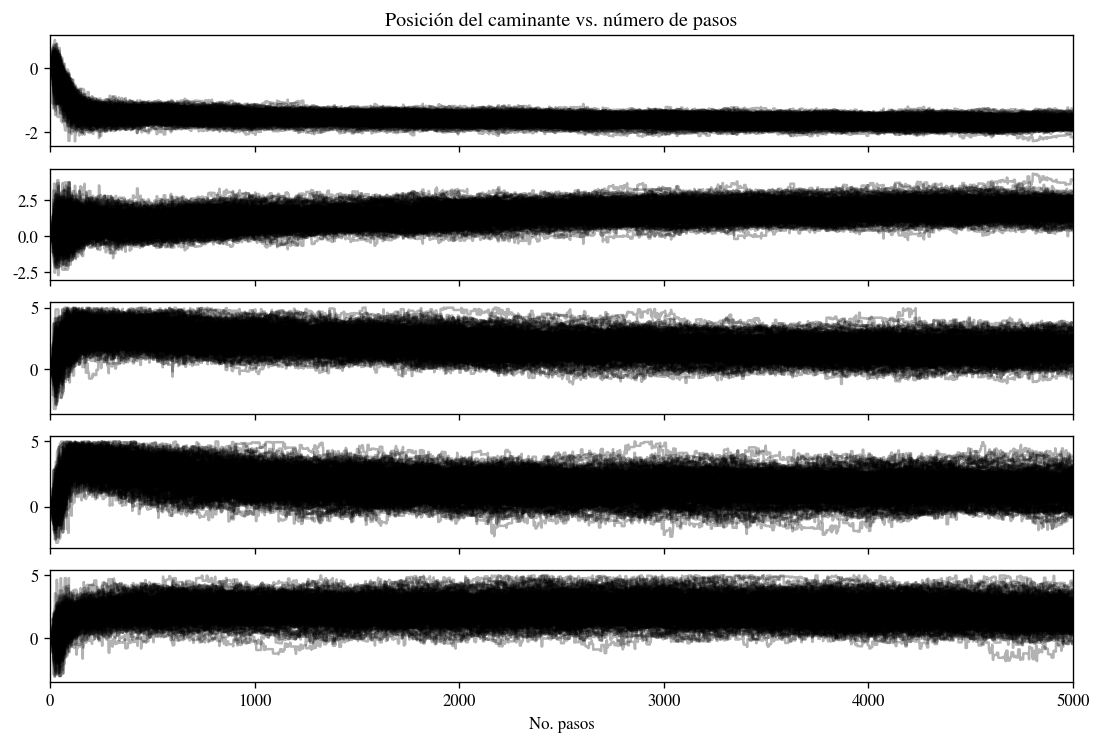

In [100]:
#veamos que hizo el mcmc
fig, axes = plt.subplots(5,figsize = (11,7),sharex = True)
axes = np.atleast_1d(axes)
samples = sampler.get_chain() #extraemos las samples de la cadena y nos devuelve un array de (5000,n_walkers,n_params)

for i in range(5): #primeros 5
    ax = axes[i]
    ax.plot(samples[:, :, i], 'k', alpha = 0.3)
    ax.set_xlim(0,len(samples))

axes[-1].set_xlabel("No. pasos")
axes[0].set_title('Posición del caminante vs. número de pasos');

In [79]:
tau = sampler.get_autocorr_time()
print(tau)
# le tomó aprox 40 pasos a la cadena olvidar la posición inicial

AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 70 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 100;
tau: [256.306147   406.73374325 416.32820363 410.41987355 405.25090043
 388.63208156 404.40143097 390.94345718 405.10156326 455.06597355
 407.46782574 475.07345419 420.53896825 395.1658077  417.85934964
 395.25491902 409.68586666 420.81324783 436.70918143 408.0966944
 459.43385982 419.25924062 406.44059996 431.20273391 410.42634441
 416.12620307 426.36905099 404.4931624  404.99478759 486.48122408
 411.20627391 424.78708423 404.86268889 398.50293115 422.88710504
 386.78561086 451.8739304  463.59131988 415.28013828 432.48163036
 403.34081676 417.14274966 409.0497746  408.20092752 397.66286688
 412.86931975 438.07387809 460.54778064 395.90746675 413.38012844
 402.91664819 422.09145257 409.68261954 417.49507192 421.87732366
 426.99183395 409.77941666 420.91820921 410.79384956 496.60202588
 435.68413546 397.0245119  422

In [117]:
flat_samples = sampler.get_chain(discard = 200, thin = 15,flat=True)
print(flat_samples.shape)

(64000, 50)


In [118]:
cadenas = sampler.get_chain(flat = True, discard = 200,thin = 10)
print(cadenas.shape)

(96000, 50)


In [119]:
z_plot = np.linspace(z_nodes_part.min(), z_nodes_part.max(), 1000)
w_samples_interp = np.array([
    np.interp(z_plot, z_nodes_part, theta_to_w(theta, L, kappa)) for theta in cadenas
])

w_median = np.percentile(w_samples_interp, 70, axis=0)

# # 1σ → 68%
# w_low1   = np.percentile(w_samples_interp, 16,   axis=0)
# w_high1  = np.percentile(w_samples_interp, 84,   axis=0)

# 2σ → 95%
w_low2   = np.percentile(w_samples_interp,  2.5, axis=0)
w_high2  = np.percentile(w_samples_interp, 97.5, axis=0)

# 3σ → 99.7%
w_low3   = np.percentile(w_samples_interp,  0.15, axis=0)
w_high3  = np.percentile(w_samples_interp, 99.85, axis=0)

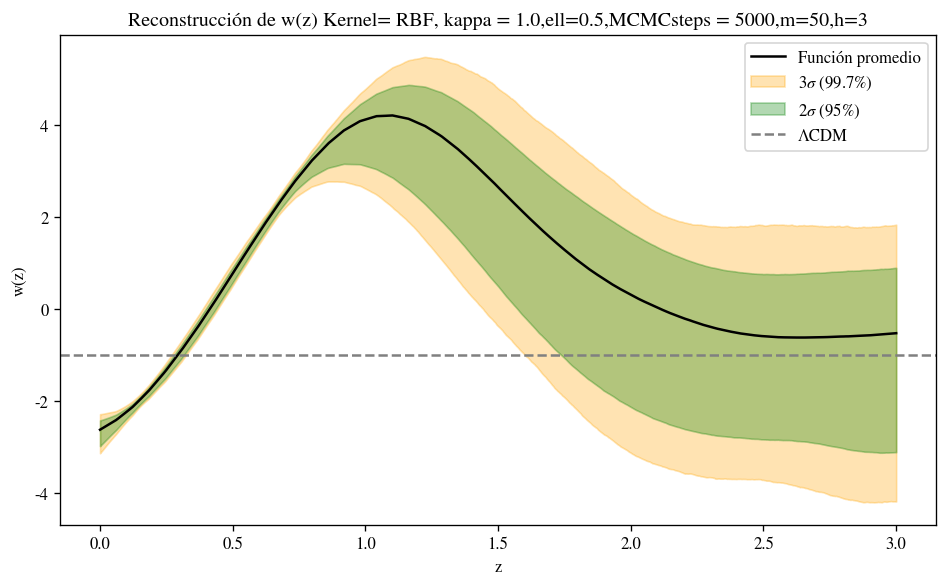

In [120]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(z_plot, w_median, color="black", label="Función promedio")

# Orden: primero el más ancho (3σ), para que no tape los internos
ax.fill_between(z_plot, w_low3, w_high3, alpha=0.3, color="orange", label=r"3$\sigma$ (99.7%)")
ax.fill_between(z_plot, w_low2, w_high2, alpha=0.3, color="green", label=r"2$\sigma$ (95%)")
#ax.fill_between(z_plot, w_low1, w_high1, alpha=0.40, color="steelblue", label=r"1$\sigma$ (68%)")

ax.axhline(-1, color="gray", linestyle="--", label="ΛCDM")
ax.set_xlabel("z")
ax.set_ylabel("w(z)")
ax.legend()
plt.title('Reconstrucción de w(z) Kernel= RBF, kappa = 1.0,ell=0.5,MCMCsteps = 5000,m=50,h=3')
plt.tight_layout()
plt.show()

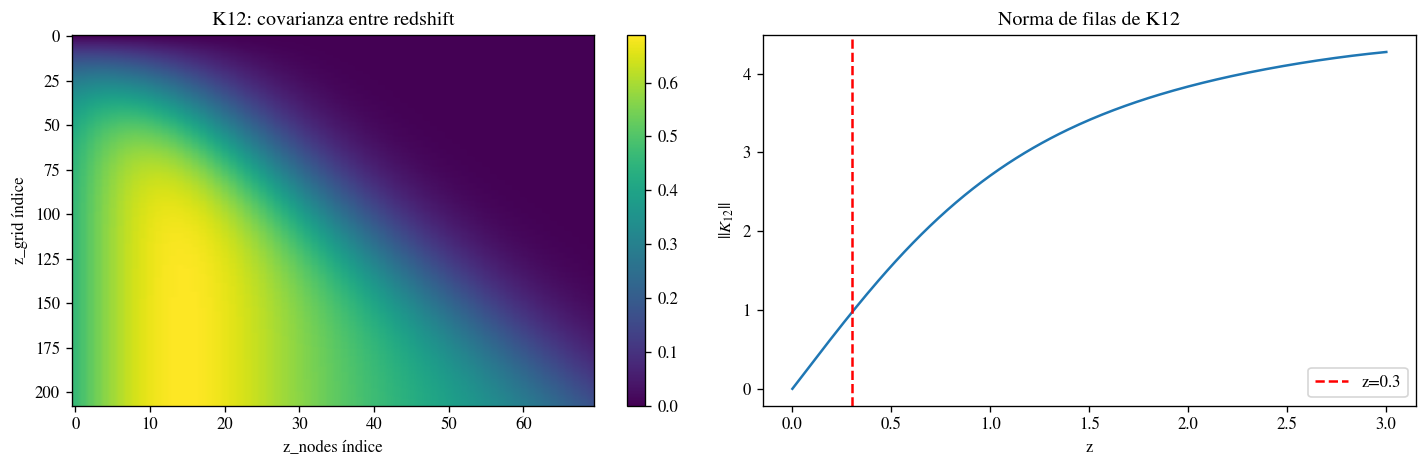

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


# K12: covarianza entre distancias y nodos w(z)
im1 = axes[0].imshow(K12, aspect='auto', cmap='viridis')
axes[0].set_title('K12: covarianza entre redshift')
axes[0].set_xlabel('z_nodes índice')
axes[0].set_ylabel('z_grid índice')
plt.colorbar(im1, ax=axes[0])

# Norma de cada fila de K12 (poder de restricción por z)
row_norms = np.linalg.norm(K12, axis=1)
axes[1].plot(z_nodes_full, row_norms)
axes[1].set_title('Norma de filas de K12')
axes[1].set_xlabel('z')
axes[1].set_ylabel('$||K_{12}||$')
axes[1].axvline(0.3, color='r', linestyle='--', label='z=0.3')
axes[1].legend()

plt.tight_layout()
plt.show()